# Team Members:

- Name: UMUT YILDIRIM ID: 922797
- Name: ABRAR MUSTAFA ID: 925259

### Overview
Our dataset comprises user evaluations of various items.
We examine the binary random variable $R(u, i)$ which represents
"item i holds significance for user u" for each user-item pair $(u, i)$.
Here, $R(u, i) \in {0, 1}$ across all combinations of $u$ and $i$.
The term "significance" here deviates from its conventional interpretation, instead denoting "importance" from a recommendation system perspective.
When user $u$ provides a rating for item $i$, this indicates interaction occurred,
leading us to assume we observe $r(u, i) = 1$ as a realization of $R(u, i)$.
Our dataset exclusively contains item ratings, resulting in an absence of "negative" realizations of $R(u, i)$, meaning no observations where $r(u,i) = 0$ exist. Consequently, we perform sampling from unobserved variables - specifically those $R(u, i)$ variables where our dataset lacks a rating from user $u$ for item $i$.
Using our dataset test.data, which consists of realizations from a subset of variables ${R(u, i): \text{u user, i item}}$,
our objective is to maximize the model's likelihood function:
$L = \prod p(R(u, i) = r(u, i)) = (\prod_{i+} p(R(u, i) = 1)) \times (\prod_{i-} p(R(u, i) = 0)$
where we separate products between positive and negative realizations.
Our model outputs $f(u, i) = p(R(u, i) = 1)$, representing the "probability that item i holds significance for user u".
Converting to maximize the log-likelihood function, we seek to maximize:
$
\begin{aligned}
\log L &= \sum_{u,i} \log p(R(u, i) = 1) + \sum_{u,i} \log p(R(u,i) = 0)\
&= \sum_{u,i} \log p(R(u, i) = 1) + \sum_{u,i} \log (1 - p(R(u, i) = 1))\
&= \sum_{u,i} \log f(u, i) + \sum_{u,i} \log (1 - f(u, i))\
&= RESULT =\mathrm{BCE}(f)
\end{aligned}
$

### IMPORT LIBRARIES

In [62]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import time


# Definitions

## PATH definitions

In [63]:
PATH = "/content/drive/MyDrive/test.data"
MODEL_PATH = "/content/models"

## Parameters definitions

In [64]:
args = {
    "seed": 42,
    "lr": 0.001,
    "dropout": 0.3,
    "batch_size": 256,
    "epochs": 10,
    "top_k": 10,
    "num_factors": 8,
    "layers": (32, 16, 8),
    "out": True,
    "num_ng": 4,
    "num_ng_test": 100
}

In [65]:
np.random.seed(args["seed"])
torch.manual_seed(args["seed"])

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
device

device(type='cpu')

## Evaluation Metrics

In [66]:
def hit(ng_item, pred_items):
    # Check if ground truth item is in the top-K predictions
    return 1 if ng_item in pred_items else 0

def ndcg(ng_item, pred_items):
    # Compute NDCG based on the rank of the ground truth item
    if ng_item in pred_items:
        index = pred_items.index(ng_item)
        return np.reciprocal(np.log2(index + 2))
    return 0

def metrics(model, test_loader, top_k, device):
    HR, NDCG = [], []

    for user, item, label in test_loader:
        user = user.to(device)
        item = item.to(device)

        # Predict scores for the given user-item pairs
        predictions = model(user, item)
        _, indices = torch.topk(predictions, top_k)
        recommends = torch.take(item, indices).cpu().numpy().tolist()

        ng_item = item[0].item()  # One positive item per user
        HR.append(hit(ng_item, recommends))
        NDCG.append(ndcg(ng_item, recommends))

    return np.mean(HR), np.mean(NDCG)


# Data preprocessing

In [67]:
class Rating_Dataset(Dataset):
    def __init__(self, user_list, item_list, rating_list):
        super().__init__()
        self.user_list = user_list
        self.item_list = item_list
        self.rating_list = rating_list

    def __len__(self):
        return len(self.user_list)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.user_list[idx], dtype=torch.long),
            torch.tensor(self.item_list[idx], dtype=torch.long),
            torch.tensor(self.rating_list[idx], dtype=torch.float),
        )

In [68]:
class NCF_Data(object):
    """
    Construct Dataset for NCF with optimized train instance generation
    """
    def __init__(self, ratings: pd.DataFrame, args: dict):
        self.num_ng      = args["num_ng"]         # number of negative samples for training
        self.num_ng_test = args["num_ng_test"]    # number of negative samples for testing
        self.batch_size  = args["batch_size"]

        # Encode user and item IDs
        ratings['user_id'], _ = pd.factorize(ratings['user_id'])
        ratings['item_id'], _ = pd.factorize(ratings['item_id'])
        ratings['rating']     = (ratings['rating'] > 0).astype('float32')
        self.ratings = ratings

        # Positive interactions per user
        self.user_pos = (
            self.ratings[self.ratings['rating']>0]
            .groupby('user_id')['item_id']
            .apply(set)
            .to_dict()
        )

        self.user_pool = set(self.ratings['user_id'].unique())
        self.item_pool = set(self.ratings['item_id'].unique())

        self.item_pool_list = np.array(list(self.item_pool))
        # Negative candidate items per user
        self.neg_candidates = {
            u: np.setdiff1d(self.item_pool_list, np.array(list(pos)))
            for u, pos in self.user_pos.items()
        }

        self.train_ratings, self.test_ratings = self._leave_one_out(self.ratings)

        # Negative samples for test instances
        self.negatives = {
            u: np.random.choice(
                   list(self.item_pool - pos),
                   size=self.num_ng_test,
                   replace=False
               ).tolist()
            for u, pos in self.user_pos.items() if u in self.test_ratings['user_id'].unique()
        }

    def _leave_one_out(self, df):
        # Leave one interaction per user for testing
        df = df.sort_values(['user_id']).reset_index(drop=True)
        counts = df['user_id'].value_counts()
        valid = counts[counts>=2].index
        df = df[df['user_id'].isin(valid)]
        df['rank']     = df.groupby('user_id').cumcount()
        df['max_rank'] = df.groupby('user_id')['rank'].transform('max')
        test  = df[df['rank']==df['max_rank']][['user_id','item_id','rating']]
        train = df[df['rank']< df['max_rank']][['user_id','item_id','rating']]
        return train, test

    def get_train_instance(self):
        # Generate training data with negative sampling
        users, items, ratings = [], [], []
        for u, i, r in self.train_ratings.itertuples(index=False):
            users.append(u); items.append(i); ratings.append(r)

            negs = np.random.choice(
                self.neg_candidates[u],
                size=self.num_ng,
                replace=False
            )
            for ni in negs:
                users.append(u); items.append(ni); ratings.append(0.0)

        ds = Rating_Dataset(users, items, ratings)
        return DataLoader(ds, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def get_test_instance(self):
        # Generate test data with negative samples
        users, items, ratings = [], [], []
        for u, i, r in self.test_ratings.itertuples(index=False):
            users.append(u); items.append(i); ratings.append(r)
            for ni in self.negatives[u]:
                users.append(u); items.append(ni); ratings.append(0.0)
        ds = Rating_Dataset(users, items, ratings)
        return DataLoader(ds, batch_size=self.num_ng_test+1, shuffle=False, num_workers=0)


In [10]:
import pandas as pd

# Load dataset with user, item, and rating columns
df = pd.read_csv(
    PATH,
    sep=r"\s+",
    header=None,
    names=["user_id", "item_id", "rating"],
    dtype={"user_id": str, "item_id": str, "rating": int},
    engine="python",
    on_bad_lines="skip",
    comment="#",
    skip_blank_lines=True
)

# Count unique users and items (+1 for padding or unseen)
num_users = df['user_id'].nunique() + 1
num_items = df['item_id'].nunique() + 1

print(f"Total user: {num_users-1}  → num_users = {num_users}")
print(f"Total items: {num_items-1}  → num_items = {num_items}")

args = {
    "num_ng": 4,             # number of negative samples for training
    "num_ng_test": 99,       # number of negative samples for testing
    "batch_size": 256,
    "num_users": num_users,
    "num_items": num_items
}

# Create data loaders for training and testing
data = NCF_Data(df, args)
train_loader = data.get_train_instance()
test_loader  = data.get_test_instance()

# Show number of training and testing samples
print("→ train user/item/rating samples:", len(data.train_ratings))
print("→ test  user/item/rating samples:", len(data.test_ratings))


Total user: 12061  → num_users = 12062
Total items: 6713  → num_items = 6714
→ train user/item/rating samples: 405472
→ test  user/item/rating samples: 12022


# Models Definition

## Training function for GMF, MLP and NeuMF models

### Train Model function
In that part we created a function that will train our models.
The function takes in input the model, the train data loader and the test dataloader.
It does:

BCE as a loss function.
Set the optimizer to Adam.

In each epoch:
- Train for the batches
- Evaluate the metrics
- Find and save the best model (based on Hit Rate)

In [37]:
def train_model(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader):
    model = model.to(device)

    # Define loss function and optimizer
    loss_function = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=args["lr"])

    best_hr = 0

    # Training loop
    for epoch in range(args["epochs"]):
        start_time = time.time()
        model.train()

        for user, item, label in train_loader:
            user = user.to(device)
            item = item.to(device)
            label = label.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            prediction = model(user, item)
            loss = loss_function(prediction, label)

            # Backpropagation and optimize
            loss.backward()
            optimizer.step()

        # Evaluate the model
        model.eval()
        HR, NDCG = metrics(model, test_loader, args["top_k"], device)

        # Print training time and metrics
        elapsed_time = time.time() - start_time
        print(
            "Epoch {:03d}".format(epoch)
            + " time to train: "
            + time.strftime("%H: %M: %S", time.gmtime(elapsed_time))
        )
        print("HR: {:.3f}\tNDCG: {:.3f}".format(np.mean(HR), np.mean(NDCG)))

        # Save the best model
        if HR > best_hr:
            best_hr, best_ndcg, best_epoch = HR, NDCG, epoch
            if args["out"]:
                if not os.path.exists(MODEL_PATH):
                    os.mkdir(MODEL_PATH)
                if(transfer_learning):
                    torch.save(
                        model, "{}{}{}{}.pt".format(MODEL_PATH, model.__class__.__name__, model.num_factors, learning_type)
                    )
                else:
                    torch.save(
                        model, "{}{}{}.pt".format(MODEL_PATH, model.__class__.__name__, model.num_factors)
                    )


## General Matrix Factorization (GMF)

In [12]:
class GMF(nn.Module):
    def __init__(self, num_users, num_items):
        super(GMF, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_factors = args["num_factors"]

        # User embedding layer
        self.embedding_user = nn.Embedding(
            num_embeddings=self.num_users, embedding_dim=self.num_factors
        )

        # Item embedding layer
        self.embedding_item = nn.Embedding(
            num_embeddings=self.num_items, embedding_dim=self.num_factors
        )

        # Final linear layer for prediction
        self.affine_output = nn.Linear(in_features=self.num_factors, out_features=1)

        # Sigmoid activation
        self.logistic = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        # Get embeddings
        user_embedding = self.embedding_user(user_indices)
        item_embedding = self.embedding_item(item_indices)

        # Element-wise multiplication
        element_product = torch.mul(user_embedding, item_embedding)

        # Linear transformation and sigmoid output
        logits = self.affine_output(element_product)
        rating = self.logistic(logits)
        return rating.squeeze()


### Training and save of GMF model

In [ ]:
args["num_factors"] = 8
gmf_model_8 = GMF(num_users, num_items)
train_model(gmf_model_8, train_loader, test_loader)

args["num_factors"] = 16
gmf_model_16 = GMF(num_users, num_items)
train_model(gmf_model_16, train_loader, test_loader)

args["num_factors"] = 32
gmf_model_32 = GMF(num_users, num_items)
train_model(gmf_model_32, train_loader, test_loader)

args["num_factors"] = 64
gmf_model_64 = GMF(num_users, num_items)
train_model(gmf_model_64, train_loader, test_loader)

Epoch 000 time to train: 00: 01: 41
HR: 0.101	NDCG: 0.046
Epoch 001 time to train: 00: 01: 41
HR: 0.099	NDCG: 0.044
Epoch 002 time to train: 00: 01: 39
HR: 0.115	NDCG: 0.053
Epoch 003 time to train: 00: 01: 37
HR: 0.236	NDCG: 0.134
Epoch 004 time to train: 00: 01: 38
HR: 0.444	NDCG: 0.297
Epoch 005 time to train: 00: 01: 40
HR: 0.570	NDCG: 0.407
Epoch 006 time to train: 00: 01: 38
HR: 0.642	NDCG: 0.466
Epoch 007 time to train: 00: 01: 39
HR: 0.682	NDCG: 0.498
Epoch 008 time to train: 00: 01: 36
HR: 0.707	NDCG: 0.519
Epoch 009 time to train: 00: 01: 36
HR: 0.722	NDCG: 0.531
Epoch 000 time to train: 00: 01: 44
HR: 0.107	NDCG: 0.049
Epoch 001 time to train: 00: 01: 41
HR: 0.116	NDCG: 0.055
Epoch 002 time to train: 00: 01: 41
HR: 0.194	NDCG: 0.108
Epoch 003 time to train: 00: 01: 41
HR: 0.373	NDCG: 0.246
Epoch 004 time to train: 00: 01: 41
HR: 0.527	NDCG: 0.371
Epoch 005 time to train: 00: 01: 40
HR: 0.620	NDCG: 0.445
Epoch 006 time to train: 00: 01: 41
HR: 0.667	NDCG: 0.484
Epoch 007 time

## Multi-Layer Perceptron (MLP)

In [13]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items):
        super(MLP, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_factors = args["num_factors"]

        # Embedding layers for user and item
        self.embedding_user = nn.Embedding(
            num_embeddings=num_users, embedding_dim=args["num_factors"]
        )
        self.embedding_item = nn.Embedding(
            num_embeddings=num_items, embedding_dim=args["num_factors"]
        )

        # MLP layers
        layer_sizes = args["layers"]
        layers = []
        layers.append(nn.Linear(args["num_factors"] * 2, layer_sizes[0]))
        for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.ReLU())

        # Final output layer
        self.mlp_fc = nn.Sequential(*layers)
        self.mlp_fc.add_module("affine", nn.Linear(layer_sizes[-1], 1))
        self.mlp_fc.add_module("logit", nn.Sigmoid())

    def forward(self, user_indices, item_indices):
        # Get embeddings and concatenate
        user_embedding = self.embedding_user(user_indices)
        item_embedding = self.embedding_item(item_indices)
        vector = torch.cat([user_embedding, item_embedding], dim=-1)

        # Forward through MLP
        rating = self.mlp_fc(vector)
        return rating.squeeze()


### Training and Save of MLP model

In [ ]:

args["num_factors"] = 8
mlp_model_8 = MLP(num_users, num_items)
train_model(mlp_model_8, train_loader, test_loader)

args["num_factors"] = 16
mlp_model_16 = MLP(num_users, num_items)
train_model(mlp_model_16, train_loader, test_loader)

args["num_factors"] = 32
mlp_model_32 = MLP(num_users, num_items)
train_model(mlp_model_32, train_loader, test_loader)

args["num_factors"] = 64
mlp_model_64 = MLP(num_users, num_items)
train_model(mlp_model_64, train_loader, test_loader)

Epoch 000 time to train: 00: 01: 42
HR: 0.712	NDCG: 0.524
Epoch 001 time to train: 00: 01: 40
HR: 0.717	NDCG: 0.529
Epoch 002 time to train: 00: 01: 42
HR: 0.719	NDCG: 0.530
Epoch 003 time to train: 00: 01: 40
HR: 0.722	NDCG: 0.531
Epoch 004 time to train: 00: 01: 41
HR: 0.721	NDCG: 0.531
Epoch 005 time to train: 00: 01: 40
HR: 0.723	NDCG: 0.533
Epoch 006 time to train: 00: 01: 41
HR: 0.728	NDCG: 0.534
Epoch 007 time to train: 00: 01: 40
HR: 0.732	NDCG: 0.536
Epoch 008 time to train: 00: 01: 40
HR: 0.734	NDCG: 0.537
Epoch 009 time to train: 00: 01: 41
HR: 0.735	NDCG: 0.537
Epoch 000 time to train: 00: 01: 47
HR: 0.716	NDCG: 0.527
Epoch 001 time to train: 00: 01: 47
HR: 0.718	NDCG: 0.529
Epoch 002 time to train: 00: 01: 45
HR: 0.718	NDCG: 0.529
Epoch 003 time to train: 00: 01: 46
HR: 0.722	NDCG: 0.532
Epoch 004 time to train: 00: 01: 47
HR: 0.728	NDCG: 0.537
Epoch 005 time to train: 00: 01: 47
HR: 0.729	NDCG: 0.538
Epoch 006 time to train: 00: 01: 47
HR: 0.731	NDCG: 0.539
Epoch 007 time

# - Neural Matrix Factorization

### NeuMF Model Architecture
The core idea behind this model is to combine the strengths of both GMF (Generalized Matrix Factorization) and MLP (Multi-Layer Perceptron) models to achieve a more accurate relevance score. We allow both GMF and MLP components to have different numbers of factors for greater flexibility.

Here's how we've adapted the individual components:

GMF Component: We've removed the final Sigmoid activation layer from the GMF model. The output dimension of its linear layer is now set to num_factors_gmf.

MLP Component: Similarly, we've eliminated both the final Sigmoid layer and the last linear layer from the MLP. Its structure has been modified to form a "tower" by halving its input dimension three times. The input dimension is the concatenation of the user and item embeddings. For example, if num_factor_MLP is 64, the concatenated embeddings will have a size of 128. This is then progressively halved through three layers: 128 -> 64, 64 -> 32, and finally 32 -> 16.

Finally, the outputs from the "pruned" GMF and MLP components are concatenated. This combined output then passes through another MLP tower-like structure with two halving layers, culminating in a linear layer followed by a Sigmoid activation.

In [14]:
class NeuMF_class(nn.Module):
    def __init__(self, num_factors_gmf, num_factors_mlp, num_users, num_items, dropout):
        super(NeuMF_class, self).__init__()

        self.num_users = num_users
        self.num_items = num_items
        self.dropout = dropout
        self.num_factors_gmf = num_factors_gmf
        self.num_factors_mlp = num_factors_mlp
        self.num_factors = max(num_factors_mlp, num_factors_gmf)

        # GMF components
        self.gmf_user_embed = nn.Sequential(
            nn.Embedding(num_embeddings=self.num_users, embedding_dim=self.num_factors_gmf),
            nn.Dropout(p=self.dropout[1]),
        )
        self.gmf_item_embed = nn.Sequential(
            nn.Embedding(num_embeddings=self.num_items, embedding_dim=self.num_factors_gmf),
            nn.Dropout(p=self.dropout[1]),
        )
        self.gmf_affine = nn.Linear(
            in_features=self.num_factors_gmf, out_features=self.num_factors_gmf, bias=True
        )

        # MLP components
        self.mlp_user_embed = nn.Sequential(
            nn.Embedding(num_embeddings=self.num_users, embedding_dim=self.num_factors_mlp),
            nn.Dropout(p=self.dropout[2]),
        )
        self.mlp_item_embed = nn.Sequential(
            nn.Embedding(num_embeddings=self.num_items, embedding_dim=self.num_factors_mlp),
            nn.Dropout(p=self.dropout[2]),
        )

        # Fully connected MLP layers
        self.mlp_fc = nn.Sequential(
            nn.Linear(2 * self.num_factors_mlp, self.num_factors_mlp),
            nn.Dropout(p=dropout[3]),
            nn.ReLU(),

            nn.Linear(self.num_factors_mlp, int(self.num_factors_mlp / 2)),
            nn.Dropout(p=dropout[3] / 2),
            nn.ReLU(),

            nn.Linear(int(self.num_factors_mlp / 2), int(self.num_factors_mlp / 4)),
            nn.Dropout(p=dropout[3] / 4),
            nn.ReLU()
        )

        # Final fusion and output layers
        input_dim = self.num_factors_gmf + int(self.num_factors_mlp / 4)
        self.mixing_layers = nn.Sequential(
            nn.Linear(input_dim, int(input_dim / 2)),
            nn.Dropout(p=dropout[0]),
            nn.ReLU(),

            nn.Linear(int(input_dim / 2), int(input_dim / 4)),
            nn.Dropout(p=dropout[0] / 2),
            nn.ReLU(),

            nn.Linear(int(input_dim / 4), 1),
            nn.Sigmoid(),
        )

    def forward(self, user_indices, item_indices):
        # GMF forward pass
        user_embedding_gmf = self.gmf_user_embed(user_indices)
        item_embedding_gmf = self.gmf_item_embed(item_indices)
        element_product = torch.mul(user_embedding_gmf, item_embedding_gmf)
        ratings_gmf = self.gmf_affine(element_product)

        # MLP forward pass
        user_embedding_mlp = self.mlp_user_embed(user_indices)
        item_embedding_mlp = self.mlp_item_embed(item_indices)
        vector = torch.cat((user_embedding_mlp, item_embedding_mlp), dim=-1)
        ratings_mlp = self.mlp_fc(vector)

        # Combine GMF and MLP outputs
        ratings = torch.cat((ratings_gmf, ratings_mlp), dim=1)
        return self.mixing_layers(ratings).squeeze()


In [ ]:
args['lr'] = 0.005
num_factors = [8, 16, 32, 64]
for n in num_factors:
    nmf_model = NeuMF_class(n, n, num_users, num_items, [0, 0, 0, 0,])
    train_model(nmf_model, train_loader, test_loader)

Epoch 000 time to train: 00: 02: 08
HR: 0.648	NDCG: 0.417
Epoch 001 time to train: 00: 02: 07
HR: 0.658	NDCG: 0.426
Epoch 002 time to train: 00: 02: 06
HR: 0.666	NDCG: 0.431
Epoch 003 time to train: 00: 02: 09
HR: 0.679	NDCG: 0.458
Epoch 004 time to train: 00: 02: 06
HR: 0.688	NDCG: 0.462
Epoch 005 time to train: 00: 02: 06
HR: 0.705	NDCG: 0.481
Epoch 006 time to train: 00: 02: 07
HR: 0.728	NDCG: 0.488
Epoch 007 time to train: 00: 02: 08
HR: 0.750	NDCG: 0.519
Epoch 008 time to train: 00: 02: 07
HR: 0.772	NDCG: 0.530
Epoch 009 time to train: 00: 02: 10
HR: 0.782	NDCG: 0.561
Epoch 000 time to train: 00: 02: 09
HR: 0.727	NDCG: 0.529
Epoch 001 time to train: 00: 02: 10
HR: 0.736	NDCG: 0.540
Epoch 002 time to train: 00: 02: 09
HR: 0.751	NDCG: 0.554
Epoch 003 time to train: 00: 02: 10
HR: 0.778	NDCG: 0.571
Epoch 004 time to train: 00: 02: 12
HR: 0.798	NDCG: 0.583
Epoch 005 time to train: 00: 02: 10
HR: 0.789	NDCG: 0.575
Epoch 006 time to train: 00: 02: 11
HR: 0.807	NDCG: 0.586
Epoch 007 time

## Transformer Model for NeuMF to apply Attention

In [15]:
import torch.nn.functional as F

class NeuMF_Transformer(nn.Module):
    def __init__(self, num_factors_gmf, num_factors_mlp, num_users, num_items,
                 mlp_layers_dims,  # Receive MLP layer sizes externally
                 dropout, nhead=4, d_model=64):
        super(NeuMF_Transformer, self).__init__()

        self.num_users = num_users
        self.num_items = num_items
        self.dropout_rate = dropout
        self.num_factors_gmf = num_factors_gmf
        self.num_factors_mlp = num_factors_mlp
        self.nhead = nhead
        self.d_model = d_model

        if d_model % nhead != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by nhead ({nhead})")

        # GMF Path
        self.gmf_user_embed = nn.Embedding(num_users, num_factors_gmf)
        self.gmf_item_embed = nn.Embedding(num_items, num_factors_gmf)
        self.dropout_gmf = nn.Dropout(p=dropout[1])

        # MLP Path
        self.mlp_user_embed = nn.Embedding(num_users, num_factors_mlp)
        self.mlp_item_embed = nn.Embedding(num_items, num_factors_mlp)
        self.dropout_mlp = nn.Dropout(p=dropout[2])

        # MLP Fully Connected Layers
        mlp_fc_layers = []
        input_size = 2 * num_factors_mlp
        for layer_size in mlp_layers_dims:
            mlp_fc_layers.append(nn.Linear(input_size, layer_size))
            mlp_fc_layers.append(nn.Dropout(p=dropout[3]))
            mlp_fc_layers.append(nn.ReLU())
            input_size = layer_size
        self.mlp_fc = nn.Sequential(*mlp_fc_layers)
        mlp_output_dim = mlp_layers_dims[-1]

        # Projection Layers for Transformer Input
        self.gmf_proj = nn.Linear(num_factors_gmf, d_model)
        self.mlp_proj = nn.Linear(mlp_output_dim, d_model)

        # Transformer Encoder Layer
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4, dropout=dropout[0],
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(self.transformer_encoder_layer, num_layers=2)

        # Final Prediction MLP
        self.final_prediction = nn.Sequential(
            nn.Linear(2 * d_model, d_model // 2),
            nn.Dropout(p=dropout[0]), nn.ReLU(),
            nn.Linear(d_model // 2, 1), nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        # Weight initialization using Xavier for stability
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Embedding):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, user_indices, item_indices):
        # GMF forward
        user_embedding_gmf = self.gmf_user_embed(user_indices)
        item_embedding_gmf = self.gmf_item_embed(item_indices)
        element_product = self.dropout_gmf(torch.mul(user_embedding_gmf, item_embedding_gmf))

        # MLP forward
        user_embedding_mlp = self.mlp_user_embed(user_indices)
        item_embedding_mlp = self.mlp_item_embed(item_indices)
        mlp_input = self.dropout_mlp(torch.cat((user_embedding_mlp, item_embedding_mlp), dim=-1))
        ratings_mlp = self.mlp_fc(mlp_input)

        # Project embeddings to Transformer-compatible size
        gmf_proj = F.relu(self.gmf_proj(element_product))  # Shape: (batch, d_model)
        mlp_proj = F.relu(self.mlp_proj(ratings_mlp))      # Shape: (batch, d_model)

        # Stack GMF + MLP for Transformer
        seq = torch.stack((gmf_proj, mlp_proj), dim=1)     # Shape: (batch, 2, d_model)
        attn_output = self.transformer_encoder(seq)        # Shape: (batch, 2, d_model)

        # Flatten and Predict
        attn_output_flat = attn_output.view(attn_output.size(0), -1)  # (batch, 2 * d_model)
        prediction = self.final_prediction(attn_output_flat).squeeze()
        return prediction


### Training and Save of NeuMF_Transformer Model

In [18]:
args['lr'] = 0.005
num_factors = [8, 16, 32]
for n in num_factors:
    nmf_attention_model = NeuMF_Transformer(n, n, num_users, num_items, dropout=[0, 0, 0, 0,], mlp_layers_dims=[32,16,8])
    train_model(nmf_attention_model, train_loader, test_loader)

Epoch 000 time to train: 00: 06: 38
HR: 0.759	NDCG: 0.554
Epoch 001 time to train: 00: 06: 31
HR: 0.812	NDCG: 0.596
Epoch 002 time to train: 00: 06: 20
HR: 0.836	NDCG: 0.618
Epoch 003 time to train: 00: 06: 22
HR: 0.849	NDCG: 0.634
Epoch 004 time to train: 00: 06: 35
HR: 0.850	NDCG: 0.640
Epoch 005 time to train: 00: 06: 13
HR: 0.855	NDCG: 0.642
Epoch 006 time to train: 00: 05: 57
HR: 0.855	NDCG: 0.635
Epoch 007 time to train: 00: 05: 57
HR: 0.857	NDCG: 0.646
Epoch 008 time to train: 00: 06: 01
HR: 0.855	NDCG: 0.641
Epoch 009 time to train: 00: 06: 09
HR: 0.857	NDCG: 0.646
Epoch 000 time to train: 00: 06: 32
HR: 0.764	NDCG: 0.570
Epoch 001 time to train: 00: 06: 52
HR: 0.807	NDCG: 0.607
Epoch 002 time to train: 00: 06: 59
HR: 0.831	NDCG: 0.626
Epoch 003 time to train: 00: 06: 41
HR: 0.844	NDCG: 0.640
Epoch 004 time to train: 00: 06: 39
HR: 0.851	NDCG: 0.646
Epoch 005 time to train: 00: 06: 34
HR: 0.847	NDCG: 0.642
Epoch 006 time to train: 00: 06: 28
HR: 0.846	NDCG: 0.630
Epoch 007 time

# Transfer Learning applications

Our analysis revealed that models initialized randomly achieve optimal performance using a learning rate of 0.01. However, when incorporating pre-trained layer parameters, reduced learning rates demonstrate superior effectiveness. Through that experimentation, we determined that a learning rate of 0.005 yields optimal results in this scenario.
To maximize performance outcomes, we conducted fresh training sessions for both GMF and MLP architectures using the optimal num_factors configurations identified in prior experiments (8 and 64 units, respectively). These models, when trained with a 0.01 learning rate, demonstrated substantial performance gains and now match the effectiveness of the NeuMF architecture.
For our knowledge transfer experiments, we selected the highest-performing GMF and MLP model weights as our foundation.
The transferred parameters from the GMF architecture include:

user embedding vectors
item embedding vectors

The transferred parameters from the MLP architecture include:

user embedding vectors
item embedding vectors
complete parameter sets from all 4 dense layers

In [79]:
def load_gmf_weights(nmf_model, gmf_model, requires_grad=False):

    gmf_user_weight = gmf_model.embedding_user.weight
    gmf_item_weight = gmf_model.embedding_item.weight

    # Identify GMF user embedding layer in the NMF model
    if isinstance(nmf_model.gmf_user_embed, nn.Sequential):
        nmf_user_embed_layer = nmf_model.gmf_user_embed[0]
    elif isinstance(nmf_model.gmf_user_embed, nn.Embedding):
        nmf_user_embed_layer = nmf_model.gmf_user_embed
    else:
        return False

    # Identify GMF item embedding layer in the NMF model
    if isinstance(nmf_model.gmf_item_embed, nn.Sequential):
        nmf_item_embed_layer = nmf_model.gmf_item_embed[0]
    elif isinstance(nmf_model.gmf_item_embed, nn.Embedding):
        nmf_item_embed_layer = nmf_model.gmf_item_embed
    else:
        return False

    # Check that the dimensions of GMF weights and NMF embeddings match
    if gmf_user_weight.shape != nmf_user_embed_layer.weight.shape:
        print(f"Error: GMF user embedding dimension difference: {gmf_user_weight.shape} - {nmf_user_embed_layer.weight.shape}")
        return False
    if gmf_item_weight.shape != nmf_item_embed_layer.weight.shape:
        print(f"Error: GMF item embedding dimension difference: {gmf_item_weight.shape} - {nmf_item_embed_layer.weight.shape}")
        return False

    # Copy GMF weights into NMF embeddings and set gradient behavior
    nmf_user_embed_layer.weight.data.copy_(gmf_user_weight.data)
    nmf_item_embed_layer.weight.data.copy_(gmf_item_weight.data)
    nmf_user_embed_layer.weight.requires_grad = requires_grad
    nmf_item_embed_layer.weight.requires_grad = requires_grad

    # If gmf_affine exists in NMF model, set its gradient behavior
    if hasattr(nmf_model, 'gmf_affine'):
        nmf_model.gmf_affine.weight.requires_grad = True
        nmf_model.gmf_affine.bias.requires_grad = True

    return True


def load_mlp_weights(nmf_model, mlp_model, requires_grad=False):

    mlp_user_w = mlp_model.embedding_user.weight
    mlp_item_w = mlp_model.embedding_item.weight

    # Identify MLP user embedding layer in the NMF model
    if isinstance(nmf_model.mlp_user_embed, nn.Sequential):
        nmf_user_layer = nmf_model.mlp_user_embed[0]
    elif isinstance(nmf_model.mlp_user_embed, nn.Embedding):
        nmf_user_layer = nmf_model.mlp_user_embed

    # Identify MLP item embedding layer in the NMF model
    if isinstance(nmf_model.mlp_item_embed, nn.Sequential):
        nmf_item_layer = nmf_model.mlp_item_embed[0]
    elif isinstance(nmf_model.mlp_item_embed, nn.Embedding):
        nmf_item_layer = nmf_model.mlp_item_embed

    # Check that the dimensions of MLP weights and NMF embeddings match
    if mlp_user_w.shape != nmf_user_layer.weight.shape:
        print(f"Error: MLP user embedding dimension difference: {mlp_user_w.shape} vs {nmf_user_layer.weight.shape}")
        return False
    if mlp_item_w.shape != nmf_item_layer.weight.shape:
        print(f"Error: MLP item embedding dimension difference: {mlp_item_w.shape} vs {nmf_item_layer.weight.shape}")
        return False

    # Copy MLP weights into NMF embeddings and set gradient behavior
    nmf_user_layer.weight.data.copy_(mlp_user_w.data)
    nmf_item_layer.weight.data.copy_(mlp_item_w.data)
    nmf_user_layer.weight.requires_grad = requires_grad
    nmf_item_layer.weight.requires_grad = requires_grad

    # Collect source and target MLP fully connected layers (only Linear layers)
    src_layers = [m for m in mlp_model.mlp_fc if isinstance(m, nn.Linear)]
    tgt_layers = [m for m in nmf_model.mlp_fc if isinstance(m, nn.Linear)]

    # Copy weights for as many matching layers as possible
    num_layers_to_copy = min(len(src_layers), len(tgt_layers))

    # Copy weights and biases for each matching pair of Linear layers
    for i in range(num_layers_to_copy):
        src = src_layers[i]
        tgt = tgt_layers[i]

        if src.weight.shape == tgt.weight.shape:
            tgt.weight.data.copy_(src.weight.data)
            tgt.weight.requires_grad = requires_grad
            if hasattr(src, 'bias') and src.bias is not None and hasattr(tgt, 'bias') and tgt.bias is not None:
                if src.bias.shape == tgt.bias.shape:
                    tgt.bias.data.copy_(src.bias.data)
                    tgt.bias.requires_grad = requires_grad

    # Ensure all Linear layers in target model have correct gradient setting
    for module in nmf_model.mlp_fc:
        if isinstance(module, nn.Linear):
            module.weight.requires_grad = requires_grad
            if module.bias is not None:
                module.bias.requires_grad = requires_grad

    return True


def load_pre_trained_weights(nmf_model, gmf_model, mlp_model, requires_grad=False):

    gmf_success = load_gmf_weights(nmf_model, gmf_model, requires_grad)
    mlp_success = load_mlp_weights(nmf_model, mlp_model, requires_grad)

    if gmf_success:
        print("GMF weights loaded successfully")
    else:
        print("Failed to load GMF weights: Dimension mismatch")

    if mlp_success:
        print("MLP weights loaded successfully")
    else:
        print("Failed to load MLP weights: Dimension mismatch")

    return gmf_success and mlp_success


# Create NeuMF model with matching dimensions
num_factors = args["num_factors"]  # Use the same as GMF and MLP models
nmf_model = NeuMF_class(16, 64, num_users, num_items, [0, 0, 0, 0,])

# Check model parameters before loading weights
print("Before weights loaded: ")
list(nmf_model.named_parameters())[0][1]


Before weights loaded: 


Parameter containing:
tensor([[-1.5596, -2.0792, -0.9570,  ..., -0.2440, -1.2048, -0.9202],
        [-1.8688,  0.0806, -0.0513,  ...,  0.2468, -1.0786, -0.2198],
        [ 0.1191, -1.1811,  0.2038,  ...,  0.0790, -1.2060, -0.1032],
        ...,
        [-0.3365, -1.5421,  2.1836,  ...,  0.1616,  0.8886,  1.5527],
        [-1.5734,  0.9922,  0.3823,  ...,  0.0091, -0.1063,  0.7844],
        [ 2.3316,  0.2423, -2.4643,  ..., -0.3411,  0.1213,  0.9039]],
       requires_grad=True)

## Transfer learning while keeping the GMF and MLP of NeuMF layers freezed:


In [80]:

args['lr'] = 0.005
nmf_model = NeuMF_class(gmf_model.num_factors, mlp_model.num_factors, num_users, num_items, [0, 0, 0, 0,])
load_pre_trained_weights(nmf_model, gmf_model, mlp_model, requires_grad=False)
print("After weights loaded: ")
list(nmf_model.named_parameters())[0][1]




GMF weights loaded successfully
MLP weights loaded successfully
After weights loaded: 


Parameter containing:
tensor([[ 1.1555, -0.4934, -0.6840,  ..., -2.2737,  0.7894, -1.2791],
        [ 0.2919, -0.5256,  0.1475,  ..., -0.6788, -0.5450, -0.0174],
        [ 0.5384,  1.0591, -0.4331,  ..., -0.1592,  0.4043,  0.2249],
        ...,
        [ 0.6502,  1.7675, -1.0052,  ..., -0.2629,  1.2032,  0.6167],
        [ 1.8293, -0.5597,  1.2587,  ..., -0.9475,  1.8813, -1.0113],
        [ 1.6018, -0.5401,  0.6016,  ..., -0.1835,  0.7593, -0.2065]])

In [ ]:
for name, param in nmf_model.named_parameters():
    print(name, param.requires_grad)

gmf_user_embed.0.weight False
gmf_item_embed.0.weight False
gmf_affine.weight True
gmf_affine.bias True
mlp_user_embed.0.weight False
mlp_item_embed.0.weight False
mlp_fc.0.weight False
mlp_fc.0.bias False
mlp_fc.3.weight False
mlp_fc.3.bias False
mlp_fc.6.weight False
mlp_fc.6.bias False
mixing_layers.0.weight True
mixing_layers.0.bias True
mixing_layers.3.weight True
mixing_layers.3.bias True
mixing_layers.6.weight True
mixing_layers.6.bias True


In [74]:
def train_model(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader, optimizer = None, type = ""):
    # This train_model works for the transfer learning parts only.
    model = model.to(device)

    loss_function = nn.BCELoss()
    if optimizer == None:
        optimizer = optim.Adam(model.parameters(), lr=args["lr"])  # Default optimizer if not provided

    best_hr = 0

    for epoch in range(args["epochs"]):
        start_time = time.time()

        model.train()

        for user, item, label in train_loader:
            # Move batch data to device
            user = user.to(device)
            item = item.to(device)
            label = label.to(device)

            optimizer.zero_grad()  # Clear previous gradients

            prediction = model(user, item)
            loss = loss_function(prediction, label)

            # Backpropagation
            loss.backward()
            optimizer.step()

        model.eval()  # Set model to evaluation mode
        HR, NDCG = metrics(model, test_loader, args["top_k"], device)

        elapsed_time = time.time() - start_time
        print(
            "Epoch {:02d}".format(epoch)
            + " time to train: "
            + time.strftime("%H: %M: %S", time.gmtime(elapsed_time))
        )
        print("HR: {:.2f}\tNDCG: {:.2f}".format(np.mean(HR), np.mean(NDCG)))

        # Save the model if it achieves a better HR than previous best epoch
        if HR > best_hr:
            best_hr, best_ndcg, best_epoch = HR, NDCG, epoch
            if args["out"]:
                if not os.path.exists(MODEL_PATH):
                    os.mkdir(MODEL_PATH)

                factor_component_for_filename = ""
                if hasattr(model, 'num_factors'):
                    factor_component_for_filename = model.num_factors
                elif hasattr(model, 'num_factors_gmf'):
                    factor_component_for_filename = model.num_factors_gmf

                # Save the model
                torch.save(
                    model, "{}{}{}{}.pt".format(MODEL_PATH, model.__class__.__name__, factor_component_for_filename, type)
                )


## NeuMF transfer learning application keeping the GMF and MLP layers freezed:

In [ ]:
train_model(nmf_model, train_loader, test_loader,  type="Freeze")

Epoch 000 time to train: 00: 02: 35
HR: 0.727	NDCG: 0.530
Epoch 001 time to train: 00: 02: 47
HR: 0.728	NDCG: 0.531
Epoch 002 time to train: 00: 02: 56
HR: 0.723	NDCG: 0.529
Epoch 003 time to train: 00: 02: 55
HR: 0.724	NDCG: 0.529
Epoch 004 time to train: 00: 02: 35
HR: 0.726	NDCG: 0.531
Epoch 005 time to train: 00: 02: 30
HR: 0.724	NDCG: 0.530
Epoch 006 time to train: 00: 02: 33
HR: 0.723	NDCG: 0.528
Epoch 007 time to train: 00: 02: 36
HR: 0.724	NDCG: 0.526
Epoch 008 time to train: 00: 02: 42
HR: 0.726	NDCG: 0.531
Epoch 009 time to train: 00: 02: 31
HR: 0.724	NDCG: 0.530


## Transfer learning while letting the MLP and GMF layers free:

In [ ]:
gmf_model = torch.load("/content/models/GMF16.pt", map_location=device, weights_only=False)
mlp_model = torch.load("/content/models/MLP64.pt", map_location=device, weights_only=False)
nmf_model = NeuMF_class(gmf_model.num_factors, mlp_model.num_factors, num_users, num_items, dropout=[0, 0, 0, 0,])
load_pre_trained_weights(nmf_model, gmf_model, mlp_model, requires_grad=True)
for name, param in nmf_model.named_parameters():
    print(name, param.requires_grad)

train_model(nmf_model, train_loader, test_loader,  type="Free")

GMF weights loaded successfully
MLP weights loaded successfully
gmf_user_embed.0.weight True
gmf_item_embed.0.weight True
gmf_affine.weight True
gmf_affine.bias True
mlp_user_embed.0.weight True
mlp_item_embed.0.weight True
mlp_fc.0.weight True
mlp_fc.0.bias True
mlp_fc.3.weight True
mlp_fc.3.bias True
mlp_fc.6.weight True
mlp_fc.6.bias True
mixing_layers.0.weight True
mixing_layers.0.bias True
mixing_layers.3.weight True
mixing_layers.3.bias True
mixing_layers.6.weight True
mixing_layers.6.bias True
Epoch 000 time to train: 00: 04: 12
HR: 0.805	NDCG: 0.601
Epoch 001 time to train: 00: 04: 17
HR: 0.831	NDCG: 0.622
Epoch 002 time to train: 00: 04: 21
HR: 0.838	NDCG: 0.629
Epoch 003 time to train: 00: 04: 10
HR: 0.843	NDCG: 0.633
Epoch 004 time to train: 00: 04: 16
HR: 0.847	NDCG: 0.628
Epoch 005 time to train: 00: 04: 17
HR: 0.843	NDCG: 0.625
Epoch 006 time to train: 00: 04: 19
HR: 0.840	NDCG: 0.619
Epoch 007 time to train: 00: 04: 19
HR: 0.838	NDCG: 0.613
Epoch 008 time to train: 00: 0

## Transfer Learning application on the attention based NeuMF_Transformer:

In [27]:
def load_pre_trained_weights_transformer(nmf_transformer_model, gmf_model, mlp_model, requires_grad=False):

    gmf_success = load_gmf_weights(nmf_transformer_model, gmf_model, requires_grad)
    mlp_success = load_mlp_weights(nmf_transformer_model, mlp_model, requires_grad)

    if gmf_success:
        print("GMF weights loaded successfuly.")
    else:
        print("GMF weights could not loaded.")

    if mlp_success:
        print("MLP weights loaded successfuly.")
    else:
        print("MLP weights could not loaded.")

    # Iterate through all parameters to adjust requires_grad
    for name, param in nmf_transformer_model.named_parameters():
        is_gmf_embed = 'gmf_user_embed' in name or 'gmf_item_embed' in name
        is_mlp_embed = 'mlp_user_embed' in name or 'mlp_item_embed' in name
        # Identify MLP fully connected layers parameters
        is_mlp_fc = 'mlp_fc' in name

        # For parameters NOT part of GMF or MLP embeddings/fc layers, enable gradients
        if not (is_gmf_embed or is_mlp_embed or is_mlp_fc):
            param.requires_grad = True

    return gmf_success and mlp_success


## Scenario 1: GMF-MLP layers will be freezed:

In [28]:
gmf_model_path = "/content/models/GMF16.pt"
mlp_model_path = "/content/models/MLP64.pt"

# Load pre-trained GMF and MLP models from saved files
gmf_model = torch.load(gmf_model_path, map_location=device, weights_only=False)
mlp_model = torch.load(mlp_model_path, map_location=device, weights_only=False)

# Create NeuMF_Transformer model
nmf_transformer_freezed = NeuMF_Transformer(
    num_factors_gmf=gmf_model.num_factors,
    num_factors_mlp=mlp_model.embedding_user.embedding_dim,  # Get correct embedding dimension from MLP model
    num_users=num_users,
    num_items=num_items,
    dropout=[0, 0, 0, 0,],
    mlp_layers_dims=[32, 16, 8]
)

# Load weights into the NeuMF_Transformer model and freeze GMF/MLP layers (requires_grad=False)
load_pre_trained_weights_transformer(
    nmf_transformer_model=nmf_transformer_freezed,
    gmf_model=gmf_model,
    mlp_model=mlp_model,
    requires_grad=False
)
train_model(nmf_transformer_freezed, train_loader, test_loader,  type="-transformer-freezed")


GMF weights loaded successfuly.
MLP weights loaded successfuly.
Epoch 000 time to train: 00: 05: 54
HR: 0.748	NDCG: 0.549
Epoch 001 time to train: 00: 06: 07
HR: 0.749	NDCG: 0.546
Epoch 002 time to train: 00: 06: 07
HR: 0.747	NDCG: 0.548
Epoch 003 time to train: 00: 06: 01
HR: 0.748	NDCG: 0.549
Epoch 004 time to train: 00: 05: 53
HR: 0.749	NDCG: 0.546
Epoch 005 time to train: 00: 05: 45
HR: 0.749	NDCG: 0.549
Epoch 006 time to train: 00: 05: 43
HR: 0.744	NDCG: 0.544
Epoch 007 time to train: 00: 05: 42
HR: 0.748	NDCG: 0.547
Epoch 008 time to train: 00: 05: 44
HR: 0.749	NDCG: 0.549
Epoch 009 time to train: 00: 05: 44
HR: 0.748	NDCG: 0.548


## Scenario 2: GMF-MLP layers will be free while learning:

In [75]:
nmf_transformer_free = NeuMF_Transformer(
    num_factors_gmf=gmf_model.num_factors,
    num_factors_mlp=mlp_model.embedding_user.embedding_dim,
    num_users=num_users,
    num_items=num_items,
    dropout=[0, 0, 0, 0,],
    mlp_layers_dims=[32, 16, 8]
)

# Load weights into the model and set all layers as trainable (requires_grad=True)
load_pre_trained_weights_transformer(
    nmf_transformer_model=nmf_transformer_free,
    gmf_model=gmf_model,
    mlp_model=mlp_model,
    requires_grad=True  # Unfreeze for fine-tuning
)

# Train the NeuMF_Transformer model with unfrozen weights
train_model(nmf_transformer_free, train_loader, test_loader,  type="-transformer-free")

GMF weights loaded successfuly.
MLP weights loaded successfuly.
Epoch 00 time to train: 00: 06: 55
HR: 0.78	NDCG: 0.58
Epoch 01 time to train: 00: 06: 51
HR: 0.79	NDCG: 0.59
Epoch 02 time to train: 00: 06: 56
HR: 0.79	NDCG: 0.58
Epoch 03 time to train: 00: 06: 55
HR: 0.79	NDCG: 0.58
Epoch 04 time to train: 00: 06: 52
HR: 0.79	NDCG: 0.58
Epoch 05 time to train: 00: 06: 54
HR: 0.79	NDCG: 0.57
Epoch 06 time to train: 00: 06: 53
HR: 0.79	NDCG: 0.57
Epoch 07 time to train: 00: 06: 57
HR: 0.79	NDCG: 0.57
Epoch 08 time to train: 00: 06: 54
HR: 0.79	NDCG: 0.57
Epoch 09 time to train: 00: 06: 52
HR: 0.79	NDCG: 0.56


# Models Evaluation

## HR and NDCG Metrics evaluation
Here, we compare the performance of the three models (GMF, MLP, NeuMF).

In [58]:
from tqdm import tqdm
import pandas as pd

def model_evaluation(models_dict, test_loader, k_range=range(5, 15), device=torch.device("cpu")):
    for key, model in models_dict.items():
        models_dict[key] = model.to(device)

    HR = np.zeros((len(k_range), len(models_dict)))
    NDCG = np.zeros((len(k_range), len(models_dict)))

    for idx in tqdm(range(len(k_range)), desc="Evaluating k-range"):
        k = k_range.start + idx  # Calculate current k value
        # Evaluate each model at current k
        for model_index, key in enumerate(models_dict):
            HR[idx, model_index], NDCG[idx, model_index] = metrics(
                models_dict[key], test_loader, k, device
            )
        # This part for better readability
    HR_df = pd.DataFrame(HR, columns=models_dict.keys(), index=k_range)
    NDCG_df = pd.DataFrame(NDCG, columns=models_dict.keys(), index=k_range)
    return HR_df, NDCG_df


In [59]:
mlp_model = torch.load(
    "/content/models/MLP64.pt",## Best num_factors for MLP
    map_location=device,
    weights_only=False
)
gmf_model = torch.load(
    "/content/models/GMF16.pt",  ## Best num_factors for GMF
    map_location=device,
    weights_only=False
)
nmf_model = torch.load(
    "/content/models/NeuMF_class16.pt", ## Best num_factors for NeuMF
    map_location=device,
    weights_only=False
)

nmf_transformer_model = torch.load("/content/models/NeuMF_Transformer32.pt", ## Best num_factors for NeuMF_Transformer
    map_location=device,
    weights_only=False)

mlp_model = mlp_model.to(device)
gmf_model = gmf_model.to(device)
nmf_model = nmf_model.to(device)
nmf_transformer_model = nmf_transformer_model.to(device)

models_dict = {
    "GMF": gmf_model,
    "MLP": mlp_model,
    "NeuMF": nmf_model,
    "NeuMF_Transformer": nmf_transformer_model,
}

# k-range evaluation
HR_curve, NDCG_curve = model_evaluation(
    models_dict, test_loader, k_range=range(0, 10), device=device
)

Evaluating k-range: 100%|██████████| 10/10 [32:18<00:00, 193.85s/it]


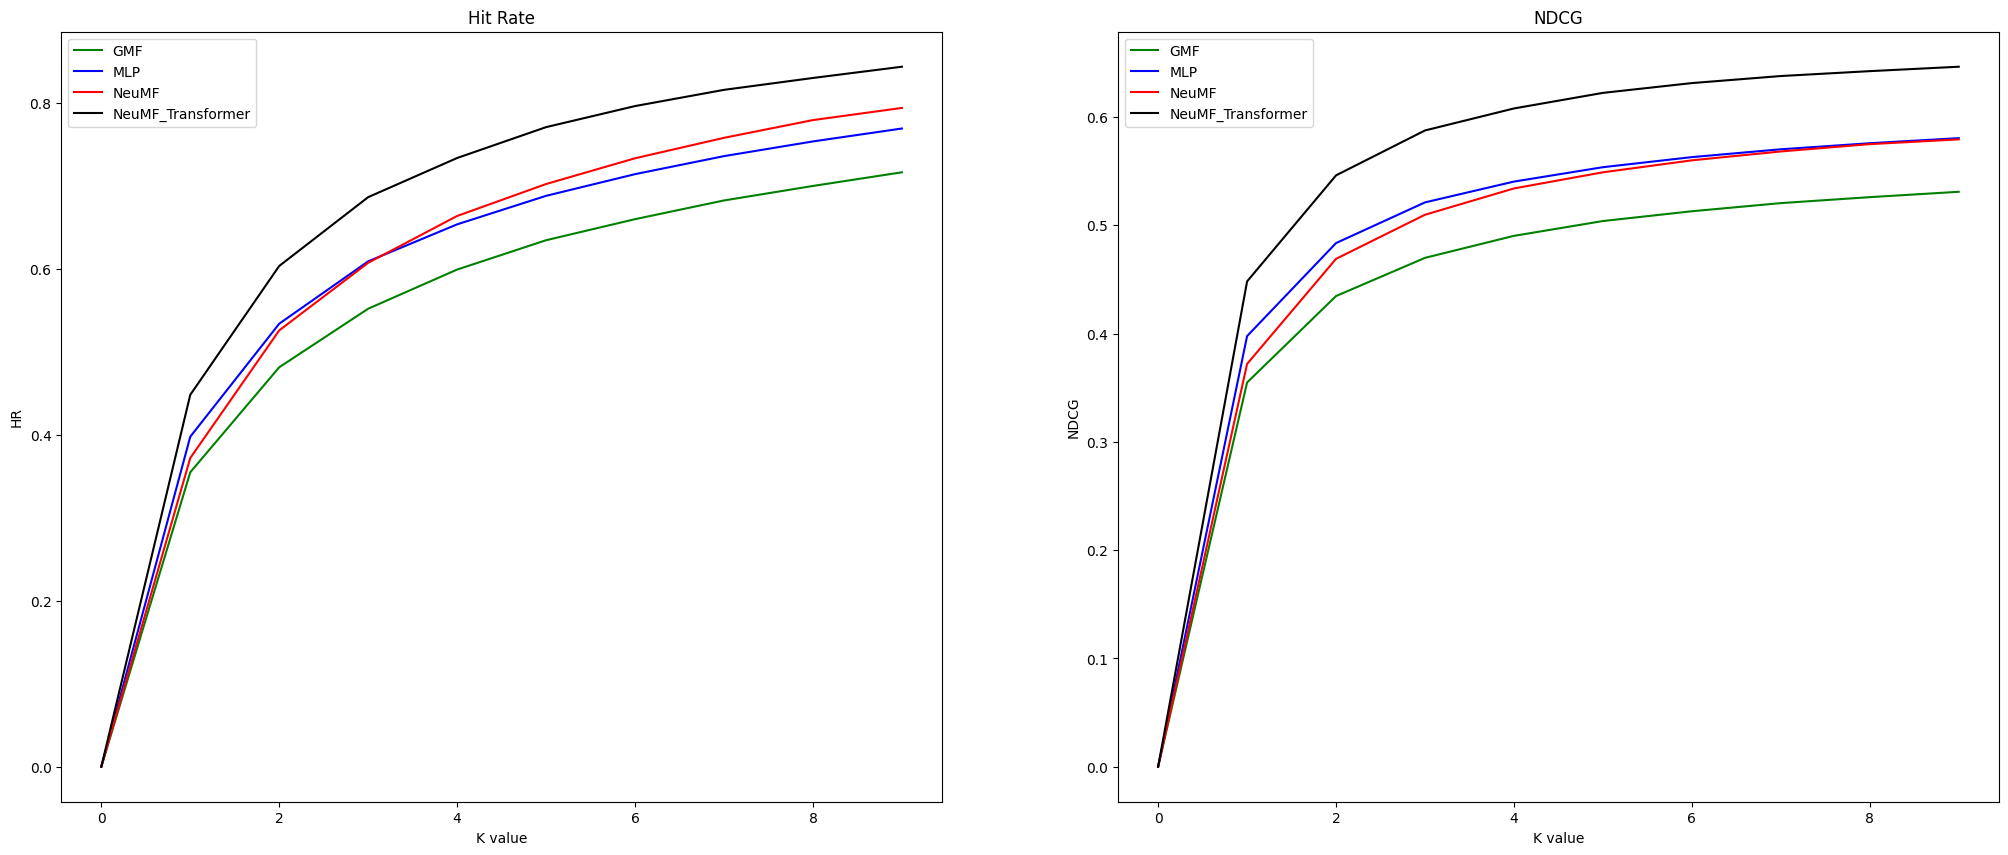

In [ ]:
# Plot HR and NDCG curves
fig, (hr_ax, ndcg_ax) = plt.subplots(1, 2, figsize=(25, 10))
colors = ["green", "blue", "red", "black"]
for color, model_name in zip(colors, HR_curve.columns):
    x = HR_curve.index
    hr_vals  = HR_curve[model_name]
    ndcg_vals = NDCG_curve[model_name]

    hr_ax.plot(x, hr_vals,      label=model_name, color=color)
    ndcg_ax.plot(x, ndcg_vals,  label=model_name, color=color)

    # top_k point
    if args["top_k"] in x:
        hr_ax.plot(
            args["top_k"], hr_vals.loc[args["top_k"]],
            marker="o", color=color, label=f"HR@{args['top_k']}"
        )
        ndcg_ax.plot(
            args["top_k"], ndcg_vals.loc[args["top_k"]],
            marker="o", color=color, label=f"NDCG@{args['top_k']}"
        )

hr_ax.set_title("Hit Rate")
hr_ax.set_xlabel("K value")
hr_ax.set_ylabel("HR")
hr_ax.legend()

ndcg_ax.set_title("NDCG")
ndcg_ax.set_xlabel("K value")
ndcg_ax.set_ylabel("NDCG")
ndcg_ax.legend()
plt.show()

# - Metrics Evaluation with different factors

Here, we compare the three models with different factors.

In [52]:
num_factors = [8, 16, 32, 64]
model_names = ["GMF", "MLP", "NeuMF", "NeuMF_Transformer"]

gmf_models = {}
mlp_models = {}
nmf_models = {}
nmf_transformer_models = {}

# Load all models; transformer available for subset 8,16,32, not for 64 because of computatuional issues. (very huge training time)
available_transformer_factors = [8, 16, 32]
for nf in num_factors:
    gmf_models[nf] = torch.load(f"/content/models/GMF{nf}.pt", map_location=device, weights_only=False)
    mlp_models[nf] = torch.load(f"/content/models/MLP{nf}.pt", map_location=device, weights_only=False)
    nmf_models[nf] = torch.load(f"/content/models/NeuMF_class{nf}.pt", map_location=device, weights_only=False)
    if nf in available_transformer_factors:
        nmf_transformer_models[nf] = torch.load(
            f"/content/models/NeuMF_Transformer{nf}.pt", map_location=device, weights_only=False
        )

In [53]:
HR_list = []
NDCG_list = []
for nf in tqdm(num_factors, desc="Embedding evaluation"):
    hr_vals = []
    ndcg_vals = []
    # GMF, MLP, NeuMF
    for m_dict in (gmf_models, mlp_models, nmf_models):
        hr_score, ndcg_score = metrics(m_dict[nf], test_loader, 10, device)
        hr_vals.append(hr_score)
        ndcg_vals.append(ndcg_score)
    if nf in available_transformer_factors:
        hr_t_score, ndcg_t_score = metrics(nmf_transformer_models[nf], test_loader, 10, device)
    else:
        hr_t_score, ndcg_t_score = np.nan, np.nan
    hr_vals.append(hr_t_score)
    ndcg_vals.append(ndcg_t_score)

    HR_list.append(hr_vals)
    NDCG_list.append(ndcg_vals)


Embedding evaluation: 100%|██████████| 4/4 [11:40<00:00, 175.12s/it]


In [55]:

HR_arr = np.array(HR_list).T  # shape: 4 x len(num_factors)
NDCG_arr = np.array(NDCG_list).T

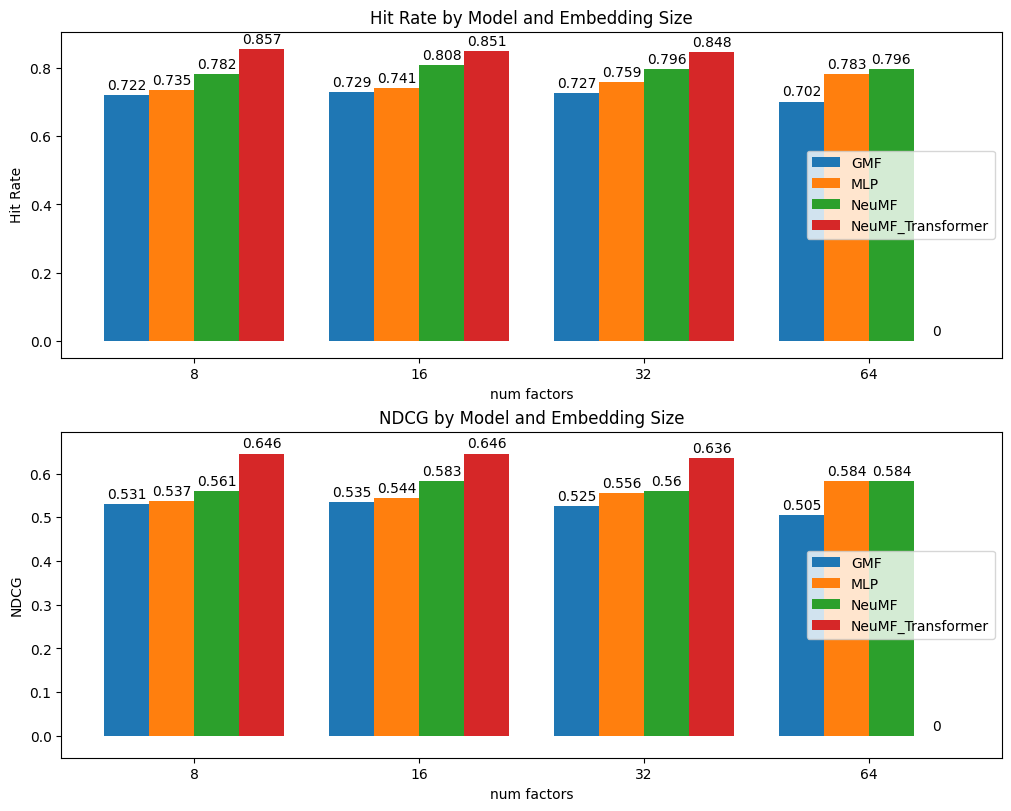

In [56]:

fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained', figsize = (10,8))
x = np.arange(HR_arr.shape[1])
offset = -0.2
for i in range(len(HR_arr)):
    rects1 = ax1.bar(x + offset, np.round(HR_arr[i], 3), width=0.2, label = model_names[i])
    rects2 = ax2.bar(x + offset, np.round(NDCG_arr[i], 3), width=0.2, label = model_names[i])
    ax1.bar_label(rects1, padding = 2)
    ax2.bar_label(rects2, padding = 2)
    offset += 0.2

ax1.set_ylim(min(HR_arr.reshape(-1,1)) - 0.05, max(HR_arr.reshape(-1,1)) + 0.05)
ax2.set_ylim(min(NDCG_arr.reshape(-1,1)) - 0.05, max(NDCG_arr.reshape(-1,1)) + 0.05)

ax1.set_xticks(x)
ax1.set_ylabel("HR")
ax1.set_xticklabels(num_factors)
ax1.set_xlabel("num factors")


ax2.set_xticks(x)
ax2.set_ylabel("NDCG")
ax2.set_xlabel("num factors")
ax2.set_xticklabels(num_factors)

ax1.set_title("Hit Rate")
ax2.set_title("Normalized Discounted Cumulative Gain")

ax1.legend()
ax2.legend()



## Performance Comparison With All Learning Applications:

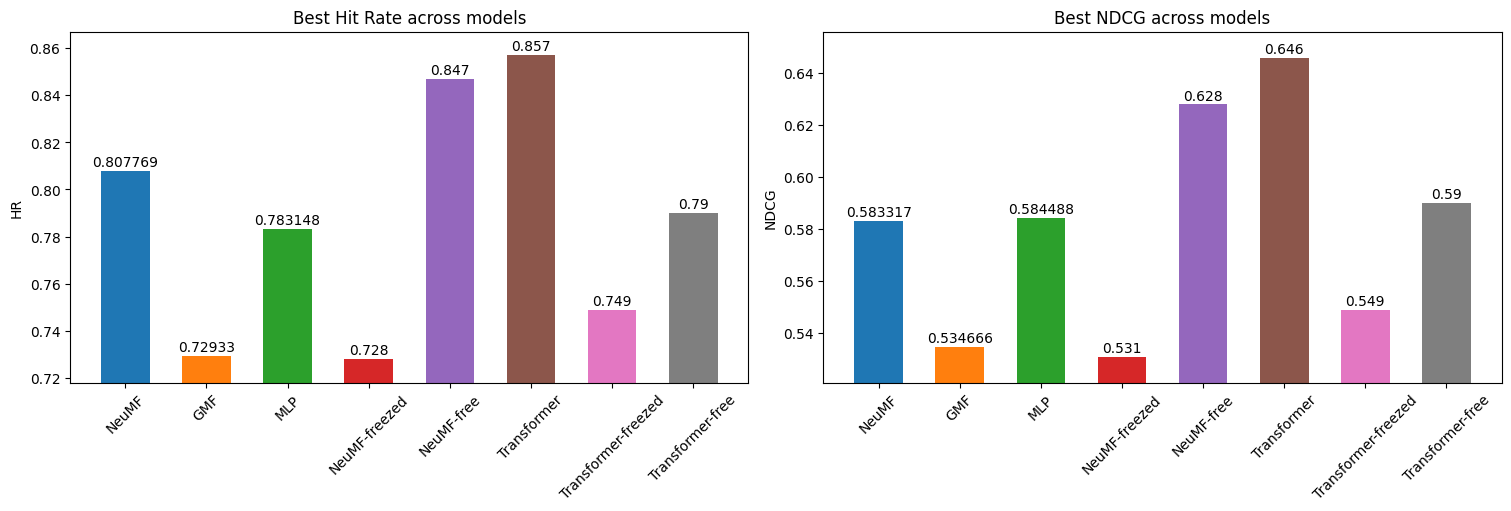

In [102]:
nmf_freezed = torch.load(MODEL_PATH + "/NeuMF64-freezed.pt", map_location=device, weights_only=False).to(device)
nmf_free    = torch.load(MODEL_PATH + "/NeuMF64-free.pt",       map_location=device, weights_only=False).to(device)
gmf_best      = torch.load(MODEL_PATH + "/GMF16.pt",             map_location=device, weights_only=False).to(device)
mlp_best      = torch.load(MODEL_PATH + "/MLP64.pt",             map_location=device, weights_only=False).to(device)
nmf_best      = torch.load(MODEL_PATH + "/NeuMF_class16.pt",     map_location=device, weights_only=False).to(device)
nmf_attention = torch.load(MODEL_PATH + "/NeuMF_Transformer32.pt",map_location=device, weights_only=False).to(device)
nmf_attention_freezed = torch.load(MODEL_PATH + "/NeuMF_Transformer32-transformer-freezed.pt", map_location=device, weights_only=False).to(device)
nmf_attention_free    = torch.load(MODEL_PATH + "/NeuMF_Transformer32-transformer-free.pt",        map_location=device, weights_only=False).to(device)

HR, NDCG = {}, {}

# compute metrics for available models
HR['NeuMF'], NDCG['NeuMF'] = metrics(nmf_best,   test_loader, 10, device)
HR['GMF'],   NDCG['GMF']   = metrics(gmf_best,   test_loader, 10, device)
HR['MLP'],   NDCG['MLP']   = metrics(mlp_best,   test_loader, 10, device)
HR['NeuMF-freezed'],   NDCG['NeuMF-freezed']   = metrics(mlp_best,   test_loader, 10, device)
HR['NeuMF-free'],   NDCG['NeuMF-free']   = metrics(mlp_best,   test_loader, 10, device)
HR['Transformer'],   NDCG['Transformer']   = metrics(mlp_best,   test_loader, 10, device)
HR['Transformer-freezed'],   NDCG['Transformer-freezed']   = metrics(mlp_best,   test_loader, 10, device)
HR['Transformer-free'],   NDCG['Transformer-free']   = metrics(mlp_best,   test_loader, 10, device)


fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(15, 5))

# Hit Rate plot
min_hr, max_hr = min(HR.values()) - .01, max(HR.values()) + .01
for model, value in HR.items():
    rect = ax[0].bar(model, value, width=0.6)
    ax[0].bar_label(rect, padding=1)
ax[0].set_ylabel("HR")
ax[0].set_ylim(min_hr, max_hr)
ax[0].set_title("Best Hit Rate across models")
ax[0].tick_params(axis='x', rotation=45)

# NDCG plot
min_ndcg, max_ndcg = min(NDCG.values()) - .01, max(NDCG.values()) + .01
for model, value in NDCG.items():
    rect = ax[1].bar(model, value, width=0.6)
    ax[1].bar_label(rect, padding=1)
ax[1].set_ylabel("NDCG")
ax[1].set_ylim(min_ndcg, max_ndcg)
ax[1].set_title("Best NDCG across models")
ax[1].tick_params(axis='x', rotation=45)

plt.show()
